In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [94]:
import pandas as pd
import numpy as np
import sys # 최대정수
from tensorflow.keras.utils import to_categorical # 분류분석시 y데이터 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로지스틱 회귀분석(이진분류)
## 1. 데이터셋 생성 & 전처리

In [3]:
# 1. csv파일을 데이터프레임으로 읽어오기(결측치처리, 균형확인 용이)
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
df.head()
# 0. 임신횟수
# 1. 2시간내 포도당 농도
# 2. 혈압
# 3. 피부접힘 두께
# 4. 인슐린수치
# 5. BMI체질량지수
# 6. 가족력
# 7. 나이
# 8. 당뇨병발병여부

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [6]:
df.info() # 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isna().sum() # 열별 결측치 갯수

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [8]:
# 타겟변수의 균형
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [9]:
df.values

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

In [10]:
# 2. csv 파일을 numpy 배열로 읽어오기 : np.loadtxt() # 이 있는 행은 제외하고 읽어오기
          # (기본인코딩 cp949)
dataset = np.loadtxt('data/pima-indians-diabetes.csv', delimiter=',', encoding='utf-8')
dataset.shape

(768, 9)

In [13]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋(모델평가용)
X_train = dataset[:620, :-1]
y_train = dataset[:620,-1]
X_test = dataset[620:,:-1]
y_test = dataset[620:,-1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

## 2. 모델구성

In [23]:
model=Sequential()
# model.add(Dense(units=32, input_dim=8, #input_shape(8,)
#                activation='relu'))
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                288       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 833
Trainable params: 833
Non-trainable params: 0
_________________________________________________________________


## 3.  학습과정 설정

In [24]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 4.  학습

In [25]:
%%time
hist = model.fit(X_train, y_train, # 훈련데이터셋(학습데이터셋)
                epochs=200,
                batch_size=310,
                #validation_data=(X_test,y_text), # 검증데이터셋
                validation_split= 0.1, # 검증데이터 비율(훈련데이터에서 10%의 데이터를 검증용 데이터로 사용)
                verbose=0) # 로그출력 X

CPU times: total: 5.2 s
Wall time: 4.52 s


## 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가
- 교차표(혼동매트릭스, 성능평가지표) 그리기

In [27]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

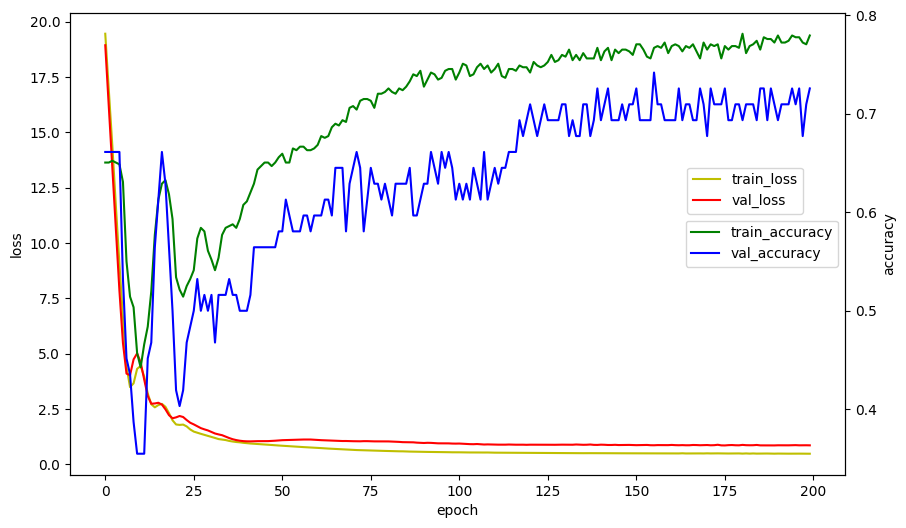

In [33]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [34]:
# 모델 평가(X)
model.evaluate(X_train, y_train)

20/20 [==============================] - 0s 467us/step - loss: 0.5131 - accuracy: 0.7710


[0.5130933523178101, 0.7709677219390869]

In [37]:
# 모델 평가(O)
score = model.evaluate(X_test, y_test)
print('loss : {}, 정확도 : {:.2f}%'. format(score[0], score[1]*100))

5/5 [==============================] - 0s 1ms/step - loss: 0.7152 - accuracy: 0.6689
loss : 0.7152479887008667, 정확도 : 66.89


In [44]:
# 교차표(혼동메트릭스, 성능평가지표) 그리기 : 테스트 셋의 실제값과 예측값
y_hat = (model.predict(X_test) >= 0.5).astype(int)
y_test.shape, y_hat.shape # 실제값(1차원), 예측값(2차원)

5/5 [==============================] - 0s 1ms/step


((148,), (148, 1))

In [45]:
y_hat.reshape(-1).shape

(148,)

In [48]:
TN = 0; FP = 0; FN = 0; TP = 0;
for y, h in zip(y_test, y_hat.reshape(-1)):
    #print(y,h)
    if y==0 and h==0:
        TN += 1 # TN갯수 하나 증가
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    elif y==1 and h==1:
        TP += 1
print(TN, FP)
print(FN, TP)

75 21
28 24


In [58]:
ctab = pd.crosstab(y_test, y_hat.reshape(-1)) # 값들이 전부 1차원이여야 함
ctab.index.name = '실제값'
ctab.columns.name ="예측값"
ctab

pd.crosstab(y_test, # 실제값
           y_hat.reshape(-1), # 예측값
           rownames=['실제값'], #index 이름
           colnames=['예측값']) #columns이름 : 결과가 데이터 프레임인 교차표

예측값,0,1
실제값,,
0.0,75,21
1.0,28,24


In [59]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # y_hat.reshape(-1) 둘다 가능
# 결과가 numpy배열인 혼동행렬

array([[75, 21],
       [28, 24]], dtype=int64)

## 6. 모델 사용(에측저장)

In [60]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [63]:
(model.predict([[2., 112.,  86.,  42., 160.,  38.4,   0.246, 28.]]) >=0.5).astype(int)

1/1 [==============================] - 0s 29ms/step


array([[0]])

In [64]:
(model.predict([[2., 112.,  86.,  42., 160.,  38.4,   0.246, 28.],
                [1, 115, 86, 42, 160, 38.4, 0.246, 60],
               ]) >=0.5).astype(int)

1/1 [==============================] - 0s 41ms/step


array([[0],
       [0]])

In [68]:
from tensorflow.keras.models import save_model, load_model
model.save('model/06binary.h5')
save_model(model, 'model/06binary.h5')

In [69]:
model2 = load_model('model/06binary.h5')

In [70]:
(model2.predict([[2., 112.,  86.,  42., 160.,  38.4,   0.246, 28.]]) >=0.5).astype(int)

1/1 [==============================] - 0s 53ms/step


array([[0]])

# 분류분석
- 1. 데이터 생성 및 전처리 : 훈련셋 600, 검증셋 100, 테스트셋 68 으로 분리, 타겟변수의 원핫인코딩
- 2. 모델생성(input 8, output 2) : 출력층의 활성화함수 : 'softmax'
- 3. 모델학습과정 loss='categorical_crossentropy' metrics=['accuracy']
- 4. 모델 학습 validation_data = [X_val,Y_val]
- 5. 모델 학습 평가
- 6. 모델 사용 - 예측 argmax()함수사용
              0     1
            0.99   0.01
            
## 1. 데이터셋 생성 및 전처리

In [72]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
dataset = df.values
dataset

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

In [96]:
# 훈련셋 600, 검증셋 100, 테스트셋 68
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val = dataset[600:700, :-1]
y_val = dataset[600:700, -1]
X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [100]:
# 분류분석을 위한 타겟(종속)변수의 원핫인코딩
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val, 2)
Y_test = to_categorical(y_test)
Y_train.shape, Y_val.shape, Y_test.shape

((600, 2), (100, 2), (68, 2))

In [76]:
print('원데이터 :', y_train[0])

원데이터 : 1.0


## 2. 모델생성(input8, target2)

In [98]:
model=Sequential()
model.add(Dense(units=32,
               input_shape=(8,),
               activation='relu'))
model.add(Dense(units=16,
               activation='relu'))
model.add(Dense(units=2,
               activation='softmax'))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 32)                288       
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 2)                 34        
                                                                 
Total params: 850
Trainable params: 850
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [99]:
model.compile(loss='categorical_crossentropy', 
             optimizer='nadam',
             metrics=['accuracy'])

## 4. 모델 학습

In [101]:
hist = model.fit(X_train, Y_train,
                epochs=200,
                validation_data=(X_val,Y_val),
                verbose=1)

Epoch 1/200
19/19 [==============================] - 1s 7ms/step - loss: 11.8484 - accuracy: 0.6367 - val_loss: 2.2149 - val_accuracy: 0.4200
Epoch 2/200
19/19 [==============================] - 0s 2ms/step - loss: 1.5176 - accuracy: 0.5583 - val_loss: 1.4159 - val_accuracy: 0.5700
Epoch 3/200
19/19 [==============================] - 0s 2ms/step - loss: 1.2516 - accuracy: 0.5867 - val_loss: 1.4352 - val_accuracy: 0.4500
Epoch 4/200
19/19 [==============================] - 0s 2ms/step - loss: 1.1063 - accuracy: 0.6150 - val_loss: 1.1204 - val_accuracy: 0.6000
Epoch 5/200
19/19 [==============================] - 0s 2ms/step - loss: 1.0180 - accuracy: 0.6367 - val_loss: 1.0553 - val_accuracy: 0.6300
Epoch 6/200
19/19 [==============================] - 0s 2ms/step - loss: 0.9334 - accuracy: 0.6467 - val_loss: 0.9958 - val_accuracy: 0.5900
Epoch 7/200
19/19 [==============================] - 0s 2ms/step - loss: 0.9575 - accuracy: 0.6467 - val_loss: 1.0036 - val_accuracy: 0.5700
Epoch 8/200


Epoch 59/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6445 - accuracy: 0.6933 - val_loss: 0.5953 - val_accuracy: 0.6900
Epoch 60/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6168 - accuracy: 0.7233 - val_loss: 0.5951 - val_accuracy: 0.6800
Epoch 61/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6244 - accuracy: 0.6933 - val_loss: 0.9863 - val_accuracy: 0.7000
Epoch 62/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6082 - accuracy: 0.6850 - val_loss: 0.5824 - val_accuracy: 0.7100
Epoch 63/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6342 - accuracy: 0.6867 - val_loss: 0.7813 - val_accuracy: 0.6000
Epoch 64/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6501 - accuracy: 0.6883 - val_loss: 0.6017 - val_accuracy: 0.6900
Epoch 65/200
19/19 [==============================] - 0s 3ms/step - loss: 0.6195 - accuracy: 0.6900 - val_loss: 0.5912 - val_accuracy: 0.7200
Epoch 

19/19 [==============================] - 0s 2ms/step - loss: 0.5573 - accuracy: 0.7283 - val_loss: 0.5733 - val_accuracy: 0.6900
Epoch 117/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5159 - accuracy: 0.7450 - val_loss: 0.5698 - val_accuracy: 0.7300
Epoch 118/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5327 - accuracy: 0.7383 - val_loss: 0.5713 - val_accuracy: 0.7000
Epoch 119/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6044 - accuracy: 0.7150 - val_loss: 0.5774 - val_accuracy: 0.7000
Epoch 120/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5527 - accuracy: 0.7283 - val_loss: 0.8663 - val_accuracy: 0.7100
Epoch 121/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5548 - accuracy: 0.7300 - val_loss: 0.6026 - val_accuracy: 0.6700
Epoch 122/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5608 - accuracy: 0.7117 - val_loss: 0.5910 - val_accuracy: 0.7100
Epoch 123/200

19/19 [==============================] - 0s 2ms/step - loss: 0.4993 - accuracy: 0.7733 - val_loss: 0.5779 - val_accuracy: 0.7300
Epoch 174/200
19/19 [==============================] - 0s 2ms/step - loss: 0.4988 - accuracy: 0.7367 - val_loss: 0.5756 - val_accuracy: 0.7500
Epoch 175/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5505 - accuracy: 0.7117 - val_loss: 0.5776 - val_accuracy: 0.7600
Epoch 176/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5647 - accuracy: 0.7150 - val_loss: 0.6753 - val_accuracy: 0.6600
Epoch 177/200
19/19 [==============================] - 0s 2ms/step - loss: 0.5038 - accuracy: 0.7667 - val_loss: 0.5625 - val_accuracy: 0.7300
Epoch 178/200
19/19 [==============================] - 0s 2ms/step - loss: 0.6096 - accuracy: 0.7117 - val_loss: 0.7638 - val_accuracy: 0.5900
Epoch 179/200
19/19 [==============================] - 0s 2ms/step - loss: 0.4828 - accuracy: 0.7650 - val_loss: 0.5719 - val_accuracy: 0.7300
Epoch 180/200

## 5.모델 평가

In [102]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

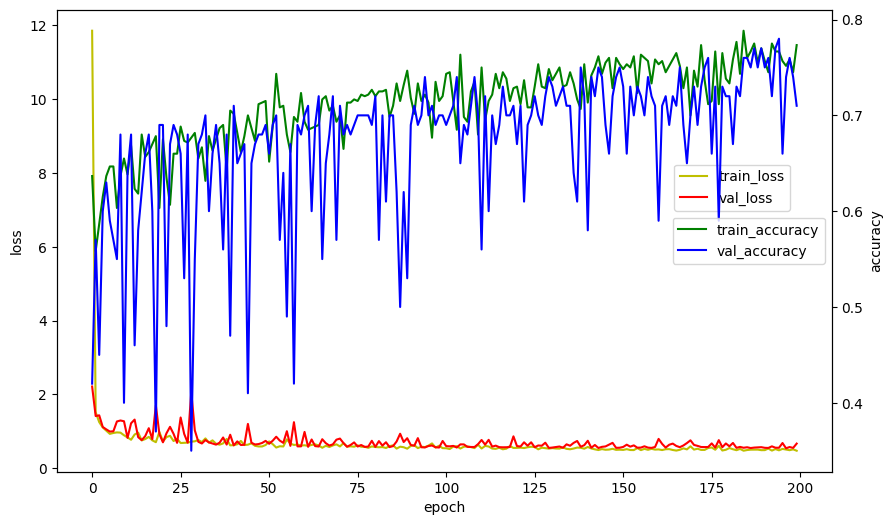

In [103]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [105]:
# 모델 평가
model.evaluate(X_test,Y_test)

3/3 [==============================] - 0s 2ms/step - loss: 0.8602 - accuracy: 0.6029


[0.8602278828620911, 0.6029411554336548]

In [110]:
# 혼동행렬, 교차표 (원핫 인코딩을 다시 복구)
# y_test 실제값
y_hat = model.predict(X_test).argmax(axis=1)

3/3 [==============================] - 0s 0s/step


In [111]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,39,2
1.0,25,2


In [112]:
confusion_matrix(y_test,y_hat)

array([[39,  2],
       [25,  2]], dtype=int64)

## 6. 모델 사용하기

In [113]:
X_test[0]

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [117]:
pred = model.predict(X_test[0].reshape(-1,8))
pred.argmax(axis=1)

1/1 [==============================] - 0s 16ms/step


array([0], dtype=int64)